# **Sample Spark Code by Emiliano Pedraza López, Physics Engineer**

#### The following ipynb is a demonstrative example of what I would regularly work on as a Data Scientist in BBVA MX via NFQ Financial Services.
#### As a Data Scientist in charge of creating a streamlined framework that would automatize the creation of regulatory reports by accessing large databases stored in S3/AWS and processing them through JupyterLabs, I have created plenty of Notebooks such as this one in which multiple resources from different databases would be accessed, streamlined and formatted to then be processed. Fields from multiple datasets would be extracted, compared and combined using Pyspark and Pandas to create the report as instructed by Mexican financial authorities. Since all of this work and the developed Notebooks are intellectually owned by BBVA, I have created random sample datasets to serve as input for this Notebook, none of this information is real sans by the information regarding currency exchange rate.



Instaling all necessary libraries and initializing a Spark session

In [8]:
!pip install pyspark

In [9]:
!pip install kagglehub[pandas-datasets]

In [10]:
from pyspark.sql import SparkSession

# Initialize the SparkSession
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("MySparkApp") \
    .getOrCreate()

In [11]:
from pyspark.sql.functions import col, to_date, regexp_replace, min, max
from pyspark.sql.functions import sum as _sum

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

#### Reading all input resources: The dataset obtained from the bank's accounting systems, from the software used for the trading operations -much like murex or calypso- and the currency exchange rate information.
The following datasets have dummy information.

In [14]:
bank_data_df= spark.read.option("header", "true").option("inferSchema", "true") .csv("/content/drive/MyDrive/Emiliano Pedraza - Portfolio/Bank_info_dummy - set.csv")
trading_ops_df=spark.read.option("header", "true").option("inferSchema", "true") .csv("/content/drive/MyDrive/Emiliano Pedraza - Portfolio/murex_calypso_daily_operations-v2.xlsx - Trading Operations.csv")

In [15]:
file_path_currency = "exchange_rates.csv"

print("Downloading and loading dataset...")
currency_df = spark.createDataFrame(kagglehub.load_dataset(\
    KaggleDatasetAdapter.PANDAS,\
    "ruchi798/currency-exchange-rates",\
    file_path_currency))

/tmp/ipykernel_12305/2492188628.py:4: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  currency_df = spark.createDataFrame(kagglehub.load_dataset(\


100%|██████████| 8.60M/8.60M [00:00<00:00, 20.0MB/s]


Inspection of each dataframe to make sure they contain the desired information and data-types.

In [16]:
bank_data_df.printSchema()
print(bank_data_df.count())

root
 |-- contract_id: integer (nullable = true)
 |-- operation_id: long (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- date: string (nullable = true)
 |-- currency: string (nullable = true)
 |-- operation_amount: integer (nullable = true)
 |-- financial_institution_id: integer (nullable = true)
 |-- operation_lifespan: string (nullable = true)
 |-- cutoff_date: string (nullable = true)
 |-- product_subclass_cd: string (nullable = true)
 |-- commercial_region_id: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- collateral_indicator: string (nullable = true)
 |-- status: string (nullable = true)
 |-- _c14: integer (nullable = true)

199


In [17]:
trading_ops_df.printSchema()
print(trading_ops_df.count())

root
 |-- operation_trade: long (nullable = true)
 |-- instrument_type: string (nullable = true)
 |-- counterparty_id: string (nullable = true)
 |-- portfolio_book: string (nullable = true)
 |-- notional_amount: string (nullable = true)
 |-- value_date: date (nullable = true)

40


In [18]:
currency_df.printSchema()
print(currency_df.count())

root
 |-- Unnamed: 0: long (nullable = true)
 |-- Country/Currency: string (nullable = true)
 |-- currency: string (nullable = true)
 |-- value: double (nullable = true)
 |-- date: string (nullable = true)

192837


It is not usually a good practice to print the dataframe, since it uses up a lot of computing power and memory, slowing down the compilation and running process. Nonetheless, here the dataframes will constantly be shown.

In [19]:
bank_data_df.show(5)

+-----------+------------+-----------+---------+--------+----------------+------------------------+------------------+-----------+-------------------+--------------------+-------+--------------------+------+----+
|contract_id|operation_id|customer_id|     date|currency|operation_amount|financial_institution_id|operation_lifespan|cutoff_date|product_subclass_cd|commercial_region_id|country|collateral_indicator|status|_c14|
+-----------+------------+-----------+---------+--------+----------------+------------------------+------------------+-----------+-------------------+--------------------+-------+--------------------+------+----+
|     428209|  8937707373|    6879162|22/8/2021|     USD|            8415|                    7860|         14/3/2024|  31/8/2021|                  E|                 638|    QAT|                   Y|     S|NULL|
|     549894|  6334542198|    3086200|5/11/2021|     EUR|             411|                    3919|         22/8/2028| 30/11/2021|                  

In [20]:
trading_ops_df.show(5)

+---------------+---------------+---------------+--------------+---------------+----------+
|operation_trade|instrument_type|counterparty_id|portfolio_book|notional_amount|value_date|
+---------------+---------------+---------------+--------------+---------------+----------+
|     1572034777|CROSS_CURR_SWAP|   BARCLAYS_LON|IR_DERIV_LATAM| 121,731,641.11|2024-03-17|
|     8880649321| BOND_SOVEREIGN|         JPM_NY|IR_DERIV_LATAM|  35,830,848.89|2024-10-04|
|     8712474009|  EQUITY_OPTION|   DEUTSCHE_FRA|IR_DERIV_LATAM|  25,246,396.33|2025-02-08|
|     4460967357| BOND_SOVEREIGN|       BBVA_MEX| EQ_DERIV_ALPH|  57,489,484.34|2022-09-26|
|     8429141456| COMMODITY_SWAP|         JPM_NY|    FX_FLOW_ST|  27,161,991.31|2022-11-09|
+---------------+---------------+---------------+--------------+---------------+----------+
only showing top 5 rows


In [21]:
currency_df.show(5)

+----------+-------------------+--------+----------+----------+
|Unnamed: 0|   Country/Currency|currency|     value|      date|
+----------+-------------------+--------+----------+----------+
|         0|   Australia Dollar|     AUD|  1.581627|17/12/2021|
|         1|Great Britain Pound|     GBP|  0.851619|17/12/2021|
|         2|               Euro|     EUR|       1.0|17/12/2021|
|         3|          Japan Yen|     JPY|128.301759|17/12/2021|
|         4|  Switzerland Franc|     CHF|  1.041015|17/12/2021|
+----------+-------------------+--------+----------+----------+
only showing top 5 rows


Formatting of the dataframes and the data

In [22]:
bank_data_df_frmttd= bank_data_df.select(
    col("contract_id").cast("int"),
    col("operation_id").cast("long"),
    col("customer_id").cast("int"),
    col("currency").cast("string"),
    col("operation_amount").cast("long"),
    to_date(col("cutoff_date"), "dd/M/yyyy").alias("cutoff_date")
    )
trading_ops_df_frmttd=trading_ops_df.select(
    col("operation_trade").cast("long"),
    col("instrument_type").cast("string"),
    col("counterparty_id").cast("string"),
    to_date(col("value_date"), "dd/M/yyyy").alias("value_date"),
    regexp_replace(col("notional_amount"), ",", "").cast("decimal(18,2)").alias("notional_amount"),
    )
currency_df_frmttd= currency_df.select(
    col("currency").cast("string").alias("currency_rate"),
    col("value").cast("double"),
    to_date(col("date"), "dd/MM/yyyy").alias("date")

)

In [23]:
bank_data_df_frmttd.show(2)

+-----------+------------+-----------+--------+----------------+-----------+
|contract_id|operation_id|customer_id|currency|operation_amount|cutoff_date|
+-----------+------------+-----------+--------+----------------+-----------+
|     428209|  8937707373|    6879162|     USD|            8415| 2021-08-31|
|     549894|  6334542198|    3086200|     EUR|             411| 2021-11-30|
+-----------+------------+-----------+--------+----------------+-----------+
only showing top 2 rows


In [24]:
trading_ops_df_frmttd.show(2)

+---------------+---------------+---------------+----------+---------------+
|operation_trade|instrument_type|counterparty_id|value_date|notional_amount|
+---------------+---------------+---------------+----------+---------------+
|     1572034777|CROSS_CURR_SWAP|   BARCLAYS_LON|2024-03-17|   121731641.11|
|     8880649321| BOND_SOVEREIGN|         JPM_NY|2024-10-04|    35830848.89|
+---------------+---------------+---------------+----------+---------------+
only showing top 2 rows


In [25]:
currency_df_frmttd.show(2)

+-------------+--------+----------+
|currency_rate|   value|      date|
+-------------+--------+----------+
|          AUD|1.581627|2021-12-17|
|          GBP|0.851619|2021-12-17|
+-------------+--------+----------+
only showing top 2 rows


The most important information to be kept is only the information that is found in both the operation_id and the operation_trade fields.


In [26]:
bank_trading_join= bank_data_df_frmttd.join(
    trading_ops_df_frmttd, bank_data_df_frmttd.operation_id==trading_ops_df_frmttd.operation_trade, "inner"
)

In [27]:
bank_trading_join.show(2)
print(bank_trading_join.count())

+-----------+------------+-----------+--------+----------------+-----------+---------------+---------------+---------------+----------+---------------+
|contract_id|operation_id|customer_id|currency|operation_amount|cutoff_date|operation_trade|instrument_type|counterparty_id|value_date|notional_amount|
+-----------+------------+-----------+--------+----------------+-----------+---------------+---------------+---------------+----------+---------------+
|     498614|  8880649321|    3720939|     CNY|            5800| 2022-09-30|     8880649321| BOND_SOVEREIGN|         JPM_NY|2024-10-04|    35830848.89|
|     403261|  9595685835|    3163016|     CHF|            9245| 2022-12-31|     9595685835|        FX_SPOT|          GS_NY|2023-04-12|    17042707.56|
+-----------+------------+-----------+--------+----------------+-----------+---------------+---------------+---------------+----------+---------------+
only showing top 2 rows
39


Now, we combine with the currency exchange information.

In [28]:
joined_df=bank_trading_join.join(
    currency_df_frmttd, (bank_trading_join.currency==currency_df_frmttd.currency_rate) & (bank_trading_join.value_date==currency_df_frmttd.date), "inner"
)

In [29]:
joined_df.show(joined_df.count())
print(joined_df.count())

+-----------+------------+-----------+--------+----------------+-----------+---------------+---------------+---------------+----------+---------------+-------------+-----------+----------+
|contract_id|operation_id|customer_id|currency|operation_amount|cutoff_date|operation_trade|instrument_type|counterparty_id|value_date|notional_amount|currency_rate|      value|      date|
+-----------+------------+-----------+--------+----------------+-----------+---------------+---------------+---------------+----------+---------------+-------------+-----------+----------+
|     595480|  1124834770|    6374689|     CHF|           24552| 2022-11-30|     1124834770| COMMODITY_SWAP|         JPM_NY|2022-01-29|    14283754.97|          CHF|   1.038161|2022-01-29|
|     512680|  1124834770|    6019974|     CNY|           35557| 2020-02-29|     1124834770| COMMODITY_SWAP|         JPM_NY|2022-01-29|    14283754.97|          CNY|   7.091514|2022-01-29|
|     439505|  1124834770|    3372471|     SEK|        

All notional amounts are standardized so that they are all expressed in EUR using the exchange rate information -typically these amounts would be expressed in USD or MXN, but given the nature of the available information from the currency exchange dataset, where all currency rates are set around EUR, the amounts will be standardized into EUR.-

In [30]:
joined_df_stndrd= joined_df.drop(
    "operation_trade",
    "currency_rate",
    "value_date"
).withColumn("notional_amount_eur", col("notional_amount")/col("value"))

In [31]:
joined_df_stndrd.show(joined_df_stndrd.count())

+-----------+------------+-----------+--------+----------------+-----------+---------------+---------------+---------------+-----------+----------+--------------------+
|contract_id|operation_id|customer_id|currency|operation_amount|cutoff_date|instrument_type|counterparty_id|notional_amount|      value|      date| notional_amount_eur|
+-----------+------------+-----------+--------+----------------+-----------+---------------+---------------+---------------+-----------+----------+--------------------+
|     595480|  1124834770|    6374689|     CHF|           24552| 2022-11-30| COMMODITY_SWAP|         JPM_NY|    14283754.97|   1.038161|2022-01-29|1.3758708880414505E7|
|     512680|  1124834770|    6019974|     CNY|           35557| 2020-02-29| COMMODITY_SWAP|         JPM_NY|    14283754.97|   7.091514|2022-01-29|  2014203.8738131237|
|     439505|  1124834770|    3372471|     SEK|            5752| 2024-01-31| COMMODITY_SWAP|         JPM_NY|    14283754.97|  10.489912|2022-01-29|  136166

Now that all information is standardized, we group by similar entries

In [32]:
final_df=joined_df_stndrd.groupBy("operation_id", "instrument_type", "counterparty_id", "date").agg(_sum("notional_amount_eur").alias("notional_amount_eur"))

In [33]:
final_df.show(final_df.count())

+------------+---------------+---------------+----------+--------------------+
|operation_id|instrument_type|counterparty_id|      date| notional_amount_eur|
+------------+---------------+---------------+----------+--------------------+
|  3141881111|        FX_SPOT|   BARCLAYS_LON|2022-07-28|2.3769908781283066E7|
|  8697488429|     FX_FORWARD|          GS_NY|2023-06-13|3.2096949602264635E7|
|  2525635753|  EQUITY_OPTION|         JPM_NY|2022-03-08| 1.047910680615047E7|
|  1124834770| COMMODITY_SWAP|         JPM_NY|2022-01-29|1.7134578607096557E7|
|  9708698626| COMMODITY_SWAP|  SANTANDER_MAD|2022-07-03| 3.740875705555963E7|
|  1861082643|  EQUITY_OPTION|        HSBC_HK|2022-04-06| 2.394016763113708E7|
|  7486151580|        FX_SPOT|       CITI_LON|2023-02-08|   4904075.113223938|
|  9595685835|        FX_SPOT|          GS_NY|2023-04-12|1.7286902342490014E7|
|  5946683622| BOND_SOVEREIGN|         JPM_NY|2022-07-24|  16242.421253592724|
|  8712474009|  EQUITY_OPTION|   DEUTSCHE_FRA|2025-0

In [34]:
final_df_pd=final_df.toPandas()

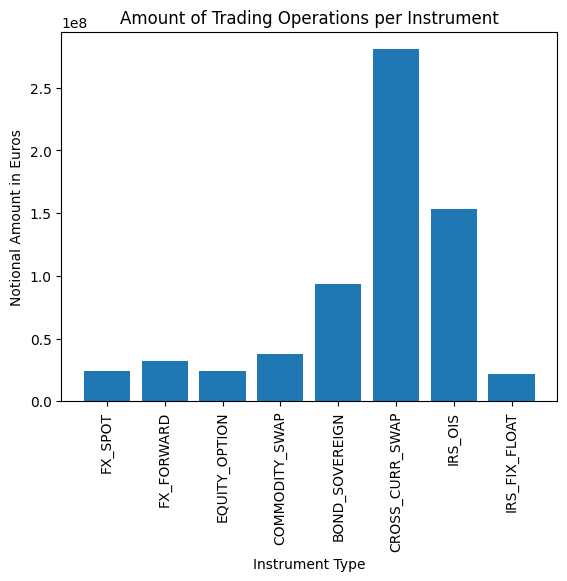

In [35]:
plt.bar(final_df_pd["instrument_type"], final_df_pd["notional_amount_eur"])
plt.xticks(rotation=90)
plt.xlabel("Instrument Type")
plt.ylabel("Notional Amount in Euros")
plt.title("Amount of Trading Operations per Instrument")
plt.show()

### The particular process and order in which it was performed here was arbitrary and not following any set criteria, simply to showcase the usage of Pyspark's prime functions and tools.